Разложение в ряд: u(x) = 1 + (-0.500) * x +  0.042 * x^2 + (-0.001) * x^3


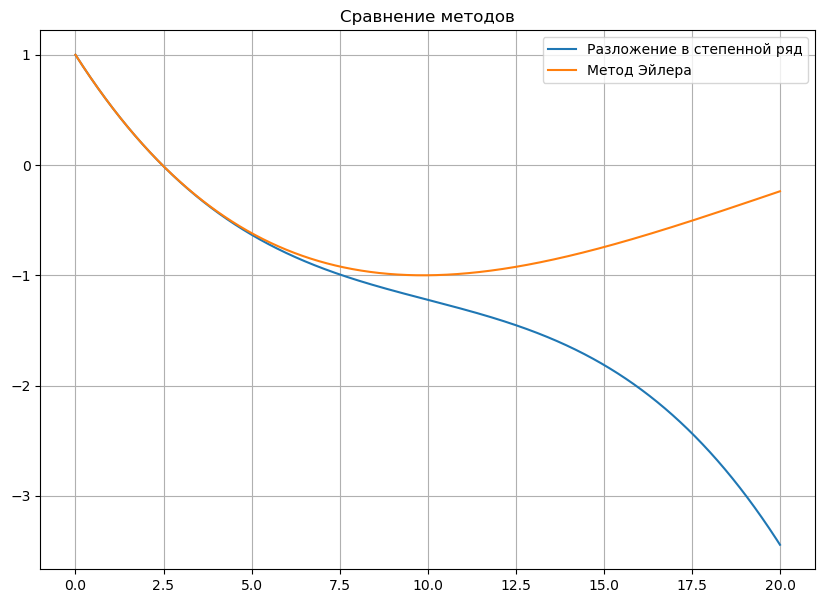

Решение разложением в степенной ряд:  u(4.0) =  -0.4222222222222223
Решение методом Эйлера:               u(4.0) =  -0.4162239345222734


In [2]:
import numpy as np
import matplotlib.pyplot as plt

# 4xu" + 2u' + u = 0
# u(0) = 1
# u'(0) = -0.5

# Найти первые четыре члена разложения в степенной ряд решения уравнения
# Сравнить результаты расчетов по полученной формуле и численным методом Эйлера.
# Нарисовать график.

# Первая производная
def get_first_derivative() -> int:
    return -0.5

# Вторая производная
def get_second_derivative() -> int:
    return 1/12

# Третья производная
def get_third_derivative() -> float:
    return -1/120

def print_u_x_by_row():
    print(f"Разложение в ряд: u(x) = 1 + " \
        f"({get_first_derivative(): .3f}) * x + " \
        f"{get_second_derivative() / 2: .3f} * x^2 + " \
        f"({get_third_derivative() / 6: .3f}) * x^3")

# Разложение в ряд (u = cos(sqrt(x)))
def get_u_x_by_row(x: int | float | np.ndarray) -> int | float | np.ndarray:
    return 1 + \
        get_first_derivative() * x + \
        get_second_derivative() / 2 * x ** 2 + \
        get_third_derivative() / 6 * x ** 3

# Численный метод Эйлера
def get_u_x_by_euler(x_val: np.ndarray, h: int | float) -> dict:
    u = 1
    u_1 = -0.5
    u_val = dict()
    
    for x in x_val:
        u_val[x] = u

        delta_u = h * u_1
        if (x != 0):
            delta_u_1 = h * -(2 * u_1 + u) / (4 * x)
        else:
            delta_u_1 = 0

        u += delta_u
        u_1 += delta_u_1

    return u_val

# График
def get_solution(x_val: np.ndarray) -> None:
    y_val_row: np.ndarray = get_u_x_by_row(x_val)
    y_val_euler: dict = get_u_x_by_euler(x_val, EULER_H)

    fig1 = plt.figure(figsize=(10, 7))
    plot = fig1.add_subplot()
    plot.plot(x_val, y_val_row, label="Разложение в степенной ряд")
    plot.plot(x_val, y_val_euler.values(), label="Метод Эйлера")
    plt.legend()
    plt.grid()
    plt.title("Сравнение методов")
    plt.show()

    try:
        arg = float(input("Введите значение аргумента: "))
    except ValueError:
        print("Неверный ввод!")
        return

    print(f"Решение разложением в степенной ряд:  u({arg}) = ", get_u_x_by_row(arg))
    print(f"Решение методом Эйлера:               u({arg}) = ", get_u_x_by_euler(np.arange(0, arg + EULER_H, EULER_H), EULER_H)[arg])

X1 = 0
X2 = 20
H = 0.001
EULER_H = 0.001

x: np.ndarray = np.arange(X1, X2, H)
print_u_x_by_row()
get_solution(x)

In [3]:
import sympy as sp
from math import cos, sqrt

x = sp.symbols('x')
u = [1]  # u₀
v = [-0.5]  # v₀

# Первое приближение (n=1)
u.append(1 + sp.integrate(v[0], (x, 0, x)))  # u₁ = 1 - 0.5x
v.append(-0.5 + sp.integrate((-u[0] - 2*v[0])/(4*x + 2), (x, 0, x)))  # v₁ = -0.5

# Второе приближение (n=2)
u.append(1 + sp.integrate(v[1], (x, 0, x)))  # u₂ = 1 - 0.5x
v.append(-0.5 + sp.integrate((-u[1] - 2*v[1])/(4*x + 2), (x, 0, x)))  # v₂ ≠ v₁

# Третье приближение (n=3)
u.append(1 + sp.integrate(v[2], (x, 0, x)))  # u₃ ≠ u₂
u = [sp.simplify(expr) for expr in u]

print("Первые три приближения для u(x):")
for i, expr in enumerate(u[:4]):
    print(f"u_{i}(x) = {expr}")


u3_func = sp.lambdify(x, u[3])
x = 0.01
print("\n", u3_func(x), cos(sqrt(x)))

Первые три приближения для u(x):
u_0(x) = 1
u_1(x) = 1 - 0.5*x
u_2(x) = 1 - 0.5*x
u_3(x) = 0.0625*x**2 - 0.0625*x*log(4.0*x + 2.0) - 0.394178301215003*x - 0.03125*log(4.0*x + 2.0) + 1.0216608493925

 0.9950000412549359 0.9950041652780258


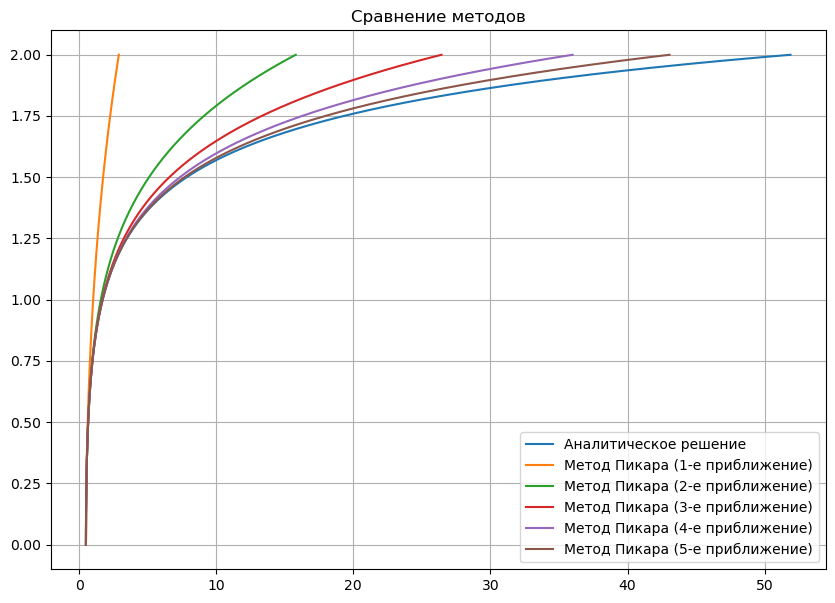

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# 1 - 2xuu' = u^3 * u'
# u(0.5) = 0

# Найти аналитическое и приближенное методом Пикара решения уравнения
# Показать, что выражение, полученное методом Пикара, сходится к точному аналитическому решению.

def get_analyt_solution(u: int | float | np.ndarray) -> int | float | np.ndarray:
    return np.exp(u ** 2) - (u ** 2) / 2 - 1 / 2

# Метод Пикара (1-е приближение)
def get_x_u_by_picar1(u: int | float | np.ndarray) -> int | float | np.ndarray:
    return 0.5 + (u ** 2) / 2 + (u ** 4) / 40

# Метод Пикара (2-е приближение)
def get_x_u_by_picar2(u: int | float | np.ndarray) -> int | float | np.ndarray:
    return 0.5 + (u ** 6) / 12 + (u ** 4) / 2 + (u ** 2) / 2

# Метод Пикара (3-е приближение)
def get_x_u_by_picar3(u: int | float | np.ndarray) -> int | float | np.ndarray:
    return 0.5 + (u ** 8) / 48 + (u ** 6) / 6 + (u ** 4) / 2 + (u ** 2) / 2

# Метод Пикара (4-е приближение)
def get_x_u_by_picar4(u: int | float | np.ndarray) -> int | float | np.ndarray:
    return 0.5 + (u ** 10) / 240 + (u ** 8) / 24 + (u ** 6) / 6 + (u ** 4) / 2 + (u ** 2) / 2

# Метод Пикара (5-е приближение)
def get_x_u_by_picar5(u: int | float | np.ndarray) -> int | float | np.ndarray:
    return 0.5 + (u ** 12) / 1440 + (u ** 10) / 120 + (u ** 8) / 24 + (u ** 6) / 6 + (u ** 4) / 2 + (u ** 2) / 2


def get_solution() -> None:
    u_val: np.ndarray | tuple[np.ndarray, float | None] = np.arange(0, 2, 0.001)
    
    fig1 = plt.figure(figsize=(10, 7))
    plot = fig1.add_subplot()
    plot.plot(get_analyt_solution(u_val), u_val, label="Аналитическое решение")
    plot.plot(get_x_u_by_picar1(u_val), u_val, label="Метод Пикара (1-е приближение)")
    plot.plot(get_x_u_by_picar2(u_val), u_val, label="Метод Пикара (2-е приближение)")
    plot.plot(get_x_u_by_picar3(u_val), u_val, label="Метод Пикара (3-е приближение)")
    plot.plot(get_x_u_by_picar4(u_val), u_val, label="Метод Пикара (4-е приближение)")
    plot.plot(get_x_u_by_picar5(u_val), u_val, label="Метод Пикара (5-е приближение)")

    plt.legend()
    plt.grid()
    plt.title("Сравнение методов")

    plt.show()

get_solution()

In [ ]:
# Считали ручками, потом сделали функции см. ниже
import numpy as np
import sympy as sp

# u'(x) = x + u^3
# u(0) = 0
# EPS = 1e-4

def f(x: int | float, u: int | float | np.ndarray) -> int | float | np.ndarray:
    return x + u ** 3

# Метод Пикара (1-е приближение)
def get_u_x_by_picar1(x: int | float | np.ndarray) -> int | float | np.ndarray:
    return x ** 2 / 2

# Метод Пикара (2-е приближение)
def get_u_x_by_picar2(x: int | float | np.ndarray) -> int | float | np.ndarray:
    return x ** 2 / 2 + x ** 7 / 56

# Метод Пикара (3-е приближение)
def get_u_x_by_picar3(x: int | float | np.ndarray) -> int | float | np.ndarray:
    return x ** 2 / 2 + \
        x ** 7 / 56 + \
        (3 * x ** 12) / 2688 + \
        (3 * x ** 17) / 106624 + \
        x ** 22 / 3863552

# Метод Пикара (4-е приближение)
def get_u_x_by_picar4(x: int | float | np.ndarray) -> int | float | np.ndarray:
    return (1 / 8) * (x ** 7) + \
           (1 / 175616) * (x ** 22) + \
           (27 / 1934917632) * (x ** 37) + \
           (27 / 120932352000) * (x ** 52) + \
           (1 / 580202171032576) * (x ** 67) + \
           (1 / 896) * (x ** 12) + \
           (3 / 36224) * (x ** 17) + \
           (3 / 141832) * (x ** 22) + \
           (1 / 51484096) * (x ** 27) + \
           (3 / 106624) * (x ** 17) + \
           (1 / 144115188075855872) * (x ** 27) + \
           (27 / 836016048000) * (x ** 37) + \
           (3 / 1392922252768000) * (x ** 47) + \
           (1 / 934912) * (x ** 27) + \
           (3 / 1114112) * (x ** 32) + \
           (1 / 410781024) * (x ** 37) + \
           (1 / 184528896) * (x ** 42) + \
           (27 / 130000000000) * (x ** 47) + \
           (27 / 24800000000000) * (x ** 57) + \
           (9 / 224 / 22) * (x ** 22) + \
           (9 / 106624 / 27) * (x ** 27) + \
           (3 / 128024576 / 32) * (x ** 32) + \
           (27 / 144115188075855872 / 32) * (x ** 32) + \
           (9 / 144115188075855872 / 37) * (x ** 37) + \
           (9 / 144115188075855872 / 42) * (x ** 42) + \
           (27 / 144115188075855872 / 37) * (x ** 37) + \
           (9 / 144115188075855872 / 42) * (x ** 42) + \
           (9 / 144115188075855872 / 47) * (x ** 47) + \
           (54 / 286720000 / 50) * (x ** 50)


x**2/2

x**7/56 + x**2/2

x**22/3863552 + 3*x**17/106624 + x**12/896 + x**7/56 + x**2/2

x**67/3863981943017739124736 + 9*x**62/98677964914244452352 + 1081*x**57/73440052228804050944 + 76623*x**52/53388985337387155456 + 310503*x**47/3244062457475366912 + 1069*x**42/224099368435712 + 790667*x**37/4145838316060672 + 11871*x**32/1883187970048 + 361*x**27/2101772288 + 47*x**22/11941888 + 33*x**17/426496 + x**12/896 + x**7/56 + x**2/2

xmax = 1.6566033935546756, umax = 89.46085027428087

x          Пикар 1 приближение  Пикар 2 приближение  Пикар 3 приближение  Пикар 4 приближение  Эйлер               
0.000      0.000                0.000                0.000                0.000                0.000               
0.010      0.000                0.000                0.000                0.000                0.000               
0.020      0.000                0.000                0.000                0.000                0.000               
0.030      0.000                0.000           

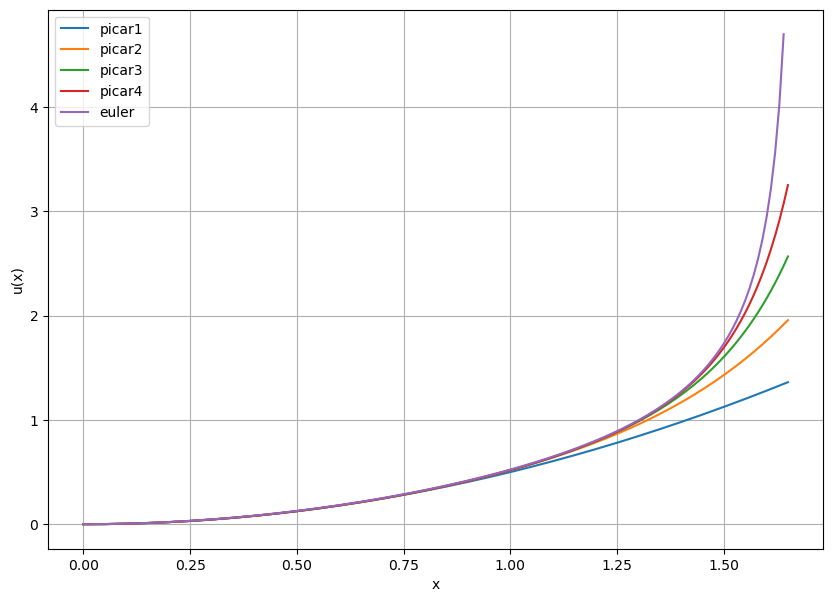

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import sympy as sp
import pandas as pd

# u'(x) = x + u^3
# u(0) = 0
# EPS = 1e-4

def f(x: int | float, u: int | float | np.ndarray) -> int | float | np.ndarray:
    return x + u ** 3

# Определение символов
x = sp.symbols('x')
u = sp.Function('u')(x)

# Явное вычисление приближений Пикара (1-4)
u1 = sp.integrate(x + 0**3, (x, 0, x))
u2 = sp.integrate(x + (x**2/2)**3, (x, 0, x))
u3 = sp.integrate(x + (u2)**3, (x, 0, x))
u4 = sp.integrate(x + (u3)**3, (x, 0, x))

print(u1, u2, u3, u4, sep='\n\n')

# Преобразование в численные функции
u1_func = sp.lambdify(x, u1, 'numpy')
u2_func = sp.lambdify(x, u2, 'numpy')
u3_func = sp.lambdify(x, u3.simplify(), 'numpy')
u4_func = sp.lambdify(x, u4.simplify(), 'numpy')

# # Численный метод Эйлера
# def get_u_x_by_euler1(x_val: np.ndarray, h: int | float) -> np.ndarray:
#     u = 0
#     u_val = []
#     for x in x_val:
#         u_val.append(u)
#         delta_u = h * f(x, u)
#         u += delta_u
#     return u_val

def get_u_x_by_euler(x_0, u_0, h_0, x_max):
    result: list = []

    prev_x = x_0
    prev_u = u_0
    h = h_0

    while prev_x + h <= x_max:
        cur_x = prev_x + h
        cur_u = prev_u + h * prev_x + h * prev_u ** 3

        h = min(0.9 * (2 / (3 * prev_u ** 2 + 1e-7)), h_0)

        result.append((cur_x, cur_u))

        prev_x = cur_x
        prev_u = cur_u

    return np.array(result)

def find_x_max_euler(x0=0.0, u0=0.0, h=0.01, tol=1e-4, max_steps=10000):
    def f(x, u):
        return x + u**3
    
    def euler_step(x, u, h):
        return x + h, u + h * f(x, u)
    
    x_n, u_n = x0, u0
    step_count = 0
    
    while step_count < max_steps:
        x_big, u_big = euler_step(x_n, u_n, h)
        x_mid, u_mid = euler_step(x_n, u_n, h / 2)
        x_half, u_half = euler_step(x_mid, u_mid, h / 2)
    
        err = abs(u_big - u_half)
    
        if err > tol:
            h /= 2
            if h < 1e-7:
                return x_n, u_n
        else:
            x_n, u_n = x_big, u_big
            step_count += 1
    
    return x_n, u_n

def print_res_table(x_val, 
                    u_val_by_picar1, 
                    u_val_by_picar2,
                    u_val_by_picar3, 
                    u_val_by_picar4, 
                    u_val_by_euler):
    header = f"{'x':<10} {'Пикар 1 приближение':<20} {'Пикар 2 приближение':<20} {'Пикар 3 приближение':<20} {'Пикар 4 приближение':<20} {'Эйлер':<20}"
    print(header)
    print("=" * len(header))
    round_ = 3
    for i in range(len(x_val) - 1):
        print(f"{x_val[i]:<10.{round_}f} {u_val_by_picar1[i]:<20.{round_}f} {u_val_by_picar2[i]:<20.{round_}f} {u_val_by_picar3[i]:<20.{round_}f} {u_val_by_picar4[i]:<20.{round_}f} {u_val_by_euler[i]:<20.{round_}f}")


def plot_graph(x_val,
               u_val_by_picar1,
               u_val_by_picar2,
               u_val_by_picar3,
               u_val_by_picar4, 
               u_val_by_euler):

    fig1 = plt.figure(figsize=(10, 7))
    plot = fig1.add_subplot()
    plot.plot(x_val, u_val_by_picar1, label="picar1")
    plot.plot(x_val, u_val_by_picar2, label="picar2")
    plot.plot(x_val, u_val_by_picar3, label="picar3")
    plot.plot(x_val, u_val_by_picar4, label="picar4")
    plot.plot(x_val[:-1], u_val_by_euler, label="euler")
    plot.set_xlabel("x")
    plot.set_ylabel("u(x)")
    plot.legend()
    plot.grid(True)
    plt.show()


def get_solution() -> None:
    # XMAX = 1.6
    X0 = 0.0
    U0 = 0.0
    STEP = 0.01

    xmax, umax = find_x_max_euler()
    print(f"\nxmax = {xmax}, umax = {umax}\n")
    x_val: np.ndarray = np.arange(0, xmax, STEP)
    u_val_by_picar1: np.ndarray = u1_func(x_val)
    u_val_by_picar2: np.ndarray = u2_func(x_val)
    u_val_by_picar3: np.ndarray = u3_func(x_val)
    u_val_by_picar4: np.ndarray = u4_func(x_val)
    u_val_by_euler: np.array = get_u_x_by_euler(X0, U0, STEP, xmax)[:, 1]

    print_res_table(x_val, 
                    u_val_by_picar1, 
                    u_val_by_picar2,
                    u_val_by_picar3, 
                    u_val_by_picar4, 
                    u_val_by_euler)

    plot_graph(x_val, 
               u_val_by_picar1, 
               u_val_by_picar2,
               u_val_by_picar3,
               u_val_by_picar4,
               u_val_by_euler)


get_solution()